<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# **Tarea Semanal 4**
#### Nahuel Siles

A partir de la siguiente plantilla, sabiendo que en banda de paso la respuesta es *Chebyshev*:

<img src='Plantilla.PNG'/>

1. Obtener la plantilla de *atenuación normalizada en frecuencia*. Indicar los valores de $\alpha_{max}$ y $\alpha_{min}$.
2. Obtener la función transferencia *normalizada* del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda.
3. Aplicar el núcleo de transformación *pasa banda* y obtener la transferencia. Factorizar convenientemente para expresar en SOS.
4. Realizar la simulación numérica en python. Graficar la respuesta en frecuencia del filtro pasa banda total, y la de las SOS.

**Bonus**

1. Simulación Circuital del filtro pasa banda implementado mediante secciones pasivas separadas por seguidores de tensión activos.
2. Dado el *pasa bajo* hallado en 2) aplicar el núcleo de transformación *pasa altos* y obtener la transferencia.
3. Dado el *pasa bajo* hallado en 2), implementarlo con pasivos y aplicar la transformación de Bruton. Obtener el valor numérico de **D** del **FDNR** siendo $Z_{FDNR}=\frac{1}{s^2 D}$

#### **Plantilla de atenuación normalizada**

Primero debemos obtener la plantilla *pasa banda* en dB por lo que normalizamos con $f_0=22kHz$ con lo cual las frecuencias de corte nos quedan:

$w_{s1}=0.77$

$w_{s2}=1.63$

$w_0=1$

La plantilla queda entonces de la siguiente manera:

<img src='PlantilladB.PNG' width="400">

Para obtener la plantilla del pasa bajos prototipo necesitamos cuatro valores: $\alpha_{max}$, $\alpha_{min}$, $\Omega_0$ y $\Omega_s$. De la plantilla pasa banda obtenemos:

$\Omega_0=1$

$\alpha_{max}=0.5$

$\alpha_{min}$ y $\Omega_s$ pueden tomar los valores dependiendo de cual frecuencia de corte tomemos ya que las bandas prohibidas no son simétricas. Para asegurar que el valor elegido sea el correcto nos quedaremos con la frecuencia que ocupe un mayor orden para satisfacer su respectivo $\alpha_{min}$. 

Primero debemos obtener $\Omega_s$ para $w_{s1}$ y $w_{s2}$ mediante la siguiente expresión:

$$
\Omega_s(w)= \frac{1}{B} \frac{w^2 - w_0^2}{w}
$$

donde $B$ es el ancho de banda, el cual puede calcularse mediante $Q=\frac{1}{B}$, siendo entonces $B=0.2$.

Por lo tanto:

$$
\Omega_{s1}=-2.64=2.64 /_{\alpha_{min}=16}
$$
$$
\Omega_{s2}=5.08 /_{\alpha_{min}=24}
$$

Como la respuesta en la banda de paso debe ser *Chebyshev* calculamos $\epsilon^2$ mediante: 
$$
\epsilon^2=10^{\frac{\alpha_{max}}{10}}-1
$$

y siendo $\alpha_{max}=0.5$

$$
\epsilon^2=0.122
$$

Para el orden "n" iteramos la siguiente expresión:

$$
\alpha_{db} = 10*log(1 + \epsilon^2 cosh^2( n*cosh^{-1}(w) ) )
$$

Siendo para $\Omega_{s1}$:

Para $\Omega_{s1}/_{\alpha_{min}=16}$, $n=3$ da un $\alpha_{min}=27.22$

Para $\Omega_{s2}/_{\alpha_{min}=24}$, $n=2$ da un $\alpha_{min}=24.96$

Por lo que finalmente nos quedamos con $\Omega_{s1}$ siendo entonces los valores de la plantilla prototipo pasa bajos:

$\Omega_0=1$

$\Omega_s=2.64$

$\alpha_{max}=0.5$

$\alpha_{min}=16$

A continuación la plantilla:

<img src='PlantillaLP.jpeg' width="400"/>

#### **Transferencia pasa bajos**

Como el filtro debe ser *Chebyshev* la transferencia tiene la siguiente forma:

$$
|T(jw)|^2 = \frac {1} {1 + \epsilon^2 * C_n ^2 (w)}
$$

Como $n=3$, $C_3(w)=4w^3-3w$, por lo que la transferencia 

$$
|T(jw)|^2= \frac{ \frac{1}{\epsilon^2 16} }{w^6-1.5w^4+0.5625w^2+ \frac{1}{\epsilon^2 16} }
$$

Pasandolo al dominio "s":

$$
|T(s)|^2= \frac{ -\frac{1}{\epsilon^2 16} }{s^6 + 1.5s^4 + 0.5625s^2 - \frac{1}{\epsilon^2 16} }
$$

Utilizando python obtenemos la transferencia prototipo pasabajos de tercer orden:

In [1]:
# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig
import sympy as sp
from IPython.display import display, Math

# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s

#Tamaño de los gráficos
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

In [2]:
num, den=sig.cheby1(3,0.5,1, analog=True)
s = sp.symbols('s')

num=np.round(num,4)
numP=sp.Poly(num,s)
den=np.round(den,4)
denP=sp.Poly(den,s)

Ts=sp.simplify(numP)/sp.simplify(denP)
display(Math(r'T(s) = ' + sp.latex(Ts)))

<IPython.core.display.Math object>

#### **Transferencia pasa banda aplicando el núcleo de transformación**

Para obtener la transferencia pasabanda debemos aplicar el núcleo de transformación:

$$
Kbp(s)= \frac{1}{B} \frac{s^2 +1}{s}
$$

Como seria muy laborioso obtener la transferencia utilizamos python para obtener el pasabanda:

In [3]:
B=0.2

numbp, denbp = sig.lp2bp(num,den, bw=B)
numbp_pol = sp.Poly(numbp,s)
denbp_pol = sp.Poly(denbp,s)

Tsbp=sp.simplify(numbp_pol)/sp.simplify(denbp_pol)

display(Math(r'T(s) = ' + sp.latex(Tsbp)))

<IPython.core.display.Math object>

Para poder aplicar esta transferencia nos conviene expresarla como secciones de segundo orden:

In [4]:
sospb = tf2sos_analog(numbp, denbp)

print_latex(a_equal_b_latex_s('T_{bp}(s)', pretty_print_SOS(sospb, displaystr=False)))

<IPython.core.display.Math object>

#### **Simulación**

A continuación se realizara la simulación de la transferencia total:

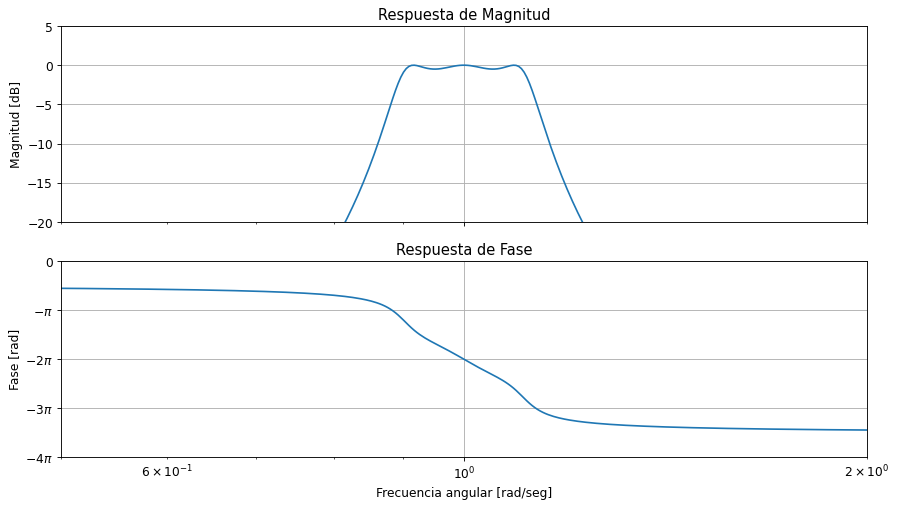

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
#Bode del pasabanda
Ts=sig.TransferFunction(numbp,denbp)
_, axes_hdl=bodePlot(Ts)

axes_hdl[0].set_xlim(1*0.5,1/0.5)
axes_hdl[0].set_ylim(-20,5)
plt.show()

#Valores límite
_, Ts1 = sig.freqresp(Ts, [0.77])
display(Math(r'\alpha_{ws1}(0.77) = ' +  sp.latex(20*np.log10(abs(Ts1[0]))) ))


_, Ts2 = sig.freqresp(Ts, [1.63])
display(Math(r'\alpha_{ws2}(1.63) = ' +  sp.latex(20*np.log10(abs(Ts2[0]))) ))

Se puede observar que logramos obtener el filtro pedido, ya que cumple con los requerimientos planteados por la plantilla.

Ahora graficaremos cada una de las secciones de segundo orden:

C:\Users\ASUS\miniconda3\envs\TdC2\Lib\site-packages\scipy\signal\_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


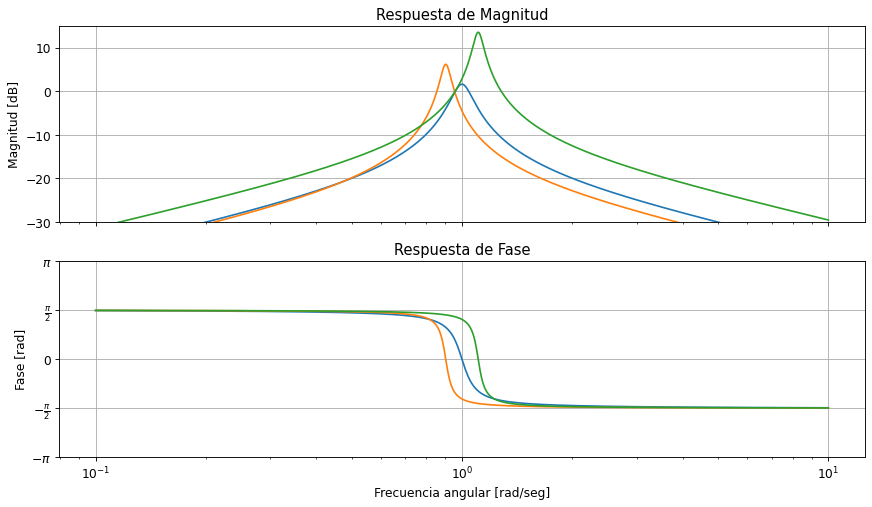

In [6]:
#Secciones individuales
H1 = sig.TransferFunction(sospb[0][0:3], sospb[0][3:6])
H2 = sig.TransferFunction(sospb[1][0:3], sospb[1][3:6])
H3 = sig.TransferFunction(sospb[2][0:3], sospb[2][3:6])

#Gráficos
_,axes=bodePlot(H1 , fig_id='one')
_=bodePlot(H2 , fig_id='one')
_=bodePlot(H3 , fig_id='one')

axes[0].set_ylim(-30,15)
plt.show()